In [1]:
import numpy as np
from scipy.ndimage import gaussian_filter1d
import matplotlib.pyplot as plt
import importlib
import pickle

import globals
import utils

In [2]:
importlib.reload(globals)
importlib.reload(utils)

<module 'utils' from 'c:\\Users\\Matteo\\Desktop\\Scuola\\MastersThesis\\Masters_Thesis\\utils.py'>

In [3]:
X, Y, wavelengths = utils.load_train_h5(globals.CURRENT_TRAIN_FILE)
wavelengths = wavelengths.squeeze()

Y_resh = Y.reshape(-1, Y.shape[1] // len(wavelengths), len(wavelengths))
print("Y reshaped:", Y_resh.shape)

Y reshaped: (500, 6, 4205)



--- Suggested CNN Spectral Windows for Path Radiance ---
Window  1: Indices    0 to  744 |  399.84 -  469.70 nm | Kernel:  3 (Complex)
Window  2: Indices  744 to 1457 |  469.70 -  564.17 nm | Kernel:  5 (Moderate)
Window  3: Indices 1457 to 4204 |  564.17 - 2506.27 nm | Kernel:  7 (Simple)

--- Suggested CNN Spectral Windows for Direct Solar Irradiance ---
Window  1: Indices    0 to 1469 |  399.84 -  566.09 nm | Kernel:  3 (Complex)
Window  2: Indices 1469 to 2320 |  566.09 -  745.71 nm | Kernel:  5 (Moderate)
Window  3: Indices 2320 to 2425 |  745.71 -  776.10 nm | Kernel:  3 (Complex)
Window  4: Indices 2425 to 3008 |  776.10 - 1003.01 nm | Kernel:  5 (Moderate)
Window  5: Indices 3008 to 3122 | 1003.01 - 1063.83 nm | Kernel:  7 (Simple)
Window  6: Indices 3122 to 3709 | 1063.83 - 1546.79 nm | Kernel:  5 (Moderate)
Window  7: Indices 3709 to 4204 | 1546.79 - 2506.27 nm | Kernel:  7 (Simple)

--- Suggested CNN Spectral Windows for Diffuse Solar Irradiance ---
Window  1: Indices    0 

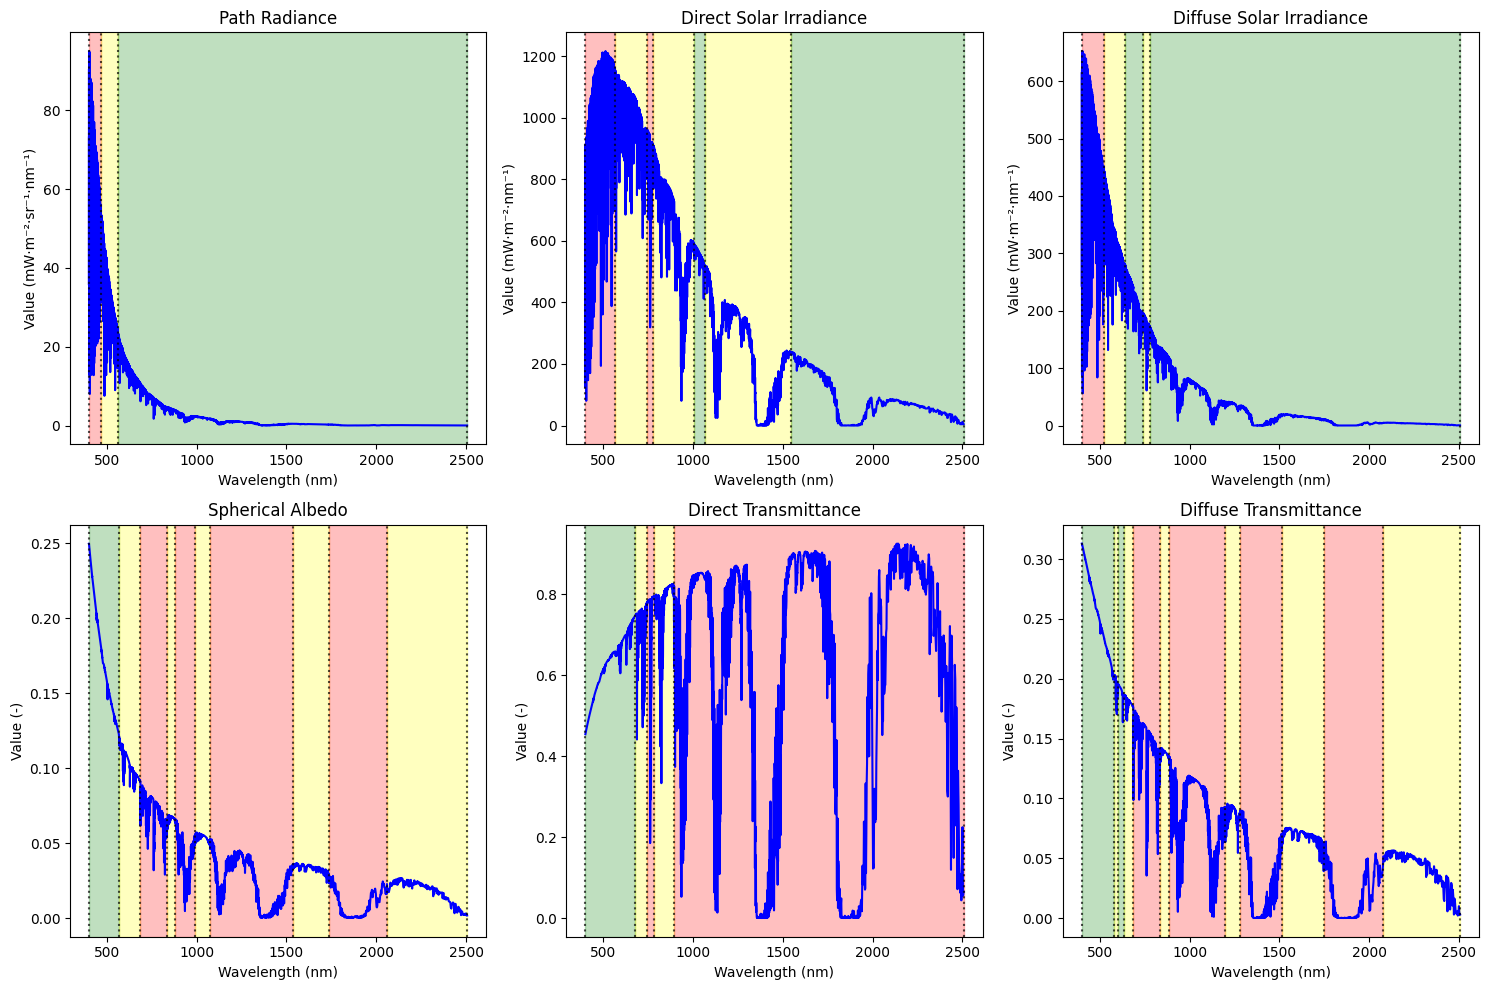

In [4]:
spectral_windows_dict = {}

kernel_sizes = [7, 5, 3]
complexity_names = ["Simple", "Moderate", "Complex"]
complexity_colors = {0: 'green', 1: 'yellow', 2: 'red'}

save_path = "nn_saves/validation_results"

for i in range(globals.N_FUNCTIONS):
    func_name = globals.function_names_plots[i]
    mean_func = np.mean(Y_resh[:, i, :], axis=0)
    
    # --- 1. normalize to 0-1 --- 
    func_min, func_max = np.min(mean_func), np.max(mean_func)
    if func_max - func_min == 0:
        norm_func = mean_func * 0
    else:
        norm_func = (mean_func - func_min) / (func_max - func_min)
        
    # --- 2. extract baseline & 3. isolate wiggles ---
    baseline = gaussian_filter1d(norm_func, sigma=30)
    wiggles = np.abs(norm_func - baseline)
    
    # --- 4. smooth wiggles ---
    smoothed_wiggles = gaussian_filter1d(wiggles, sigma=max(3, len(wavelengths) // 100))
    
    # --- 5. 3-Tier absolute thresholding ---
    max_wiggle = np.max(smoothed_wiggles)
    
    if max_wiggle < 1e-3: 
        # failsafe: the entire function is perfectly smooth -> assign label 0 (Kernel 7)
        region_labels = np.zeros_like(smoothed_wiggles, dtype=int)
    else:
        relative_complexity = smoothed_wiggles / max_wiggle
        
        # Mapping to 3 bins using 2 threshold boundaries
        thresholds = [0.10, 0.35]
        region_labels = np.digitize(relative_complexity, thresholds)

    # --- 5.5 Merge short windows (Post-processing) ---
    min_window_len = 100  # Minimum required array indices per window

    i_idx = 0
    while i_idx < len(region_labels) - 1:
        # Find current contiguous segment length
        current_label = region_labels[i_idx]
        run_len = 1
        while i_idx + run_len < len(region_labels) and region_labels[i_idx + run_len] == current_label:
            run_len += 1
        
        # If the segment is too short, overwrite it with the preceding label
        if run_len < min_window_len and i_idx > 0:
            region_labels[i_idx : i_idx + run_len] = region_labels[i_idx - 1]
        
        i_idx += run_len
        
    # --- 6. find window boundaries ---
    boundaries = np.where(np.diff(region_labels) != 0)[0]
    boundaries = np.concatenate(([0], boundaries, [len(wavelengths)-1]))

    function_windows = []
    print(f"\n--- Suggested CNN Spectral Windows for {func_name} ---")
    
    for j in range(len(boundaries) - 1):
        start = boundaries[j]
        end = boundaries[j+1]
        
        # look up tier details
        tier = region_labels[start + 1]
        complexity = complexity_names[tier]
        kernel = kernel_sizes[tier]
        
        function_windows.append({
            "window_index": j + 1,
            "start_nm": wavelengths[start],
            "end_nm": wavelengths[end],
            "complexity": complexity,
            "kernel_size": kernel,
            "tier_idx": tier
        })
        
        print(f"Window {j+1:2d}: Indices {start:4d} to {end:4d} | {wavelengths[start]:7.2f} - {wavelengths[end]:7.2f} nm | Kernel: {kernel:2d} ({complexity})")
    
    spectral_windows_dict[func_name] = function_windows

plt.figure(figsize=(15, 10))

for i in range(globals.N_FUNCTIONS):
    func_name = globals.function_names_plots[i]
    
    plt.subplot(2, 3, i+1)
    mean_func = np.mean(Y_resh[:, i, :], axis=0)
    plt.plot(wavelengths, mean_func, label="Mean", color='blue', linewidth=1.5)
    
    windows = spectral_windows_dict[func_name]
    
    for w in windows:
        plt.axvline(x=w['start_nm'], color='black', linestyle=':', alpha=0.7)
        # shade based on the 3-tier color map
        color = complexity_colors[w['tier_idx']]
        plt.axvspan(w['start_nm'], w['end_nm'], color=color, alpha=0.25)
        
    if windows:
        plt.axvline(x=windows[-1]['end_nm'], color='black', linestyle=':', alpha=0.7)

    plt.title(f"{func_name}")
    plt.xlabel("Wavelength (nm)")
    plt.ylabel(f"Value ({globals.function_units_plots[i]})")
    
plt.tight_layout()
plt.savefig(f"{save_path}/nn_spectral_windows_{X.shape[0]}", dpi=300, bbox_inches="tight")
plt.show()

In [5]:
REGION_CONFIGS = []

for i in range(globals.N_FUNCTIONS):
    func_name = globals.function_names_plots[i]
    windows = spectral_windows_dict[func_name]
    
    # extract tuples of (start_nm, end_nm, kernel_size)
    func_config = [
        (int(round(w["start_nm"])), int(round(w["end_nm"])), w["kernel_size"])
        for w in windows
    ]
    
    REGION_CONFIGS.append(func_config)

output_filename = f"nn_spectral_windows_{X.shape[0]}.pkl"
with open(f"{save_path}/{output_filename}", "wb") as f:
    pickle.dump(REGION_CONFIGS, f)

print(f"Successfully saved REGION_CONFIGS to '{output_filename}'!\n")

print("REGION_CONFIGS = [")
for i, config in enumerate(REGION_CONFIGS):
    func_name = globals.function_names_plots[i]
    print(f"    {config},  # {i}: {func_name}")
print("]")

Successfully saved REGION_CONFIGS to 'nn_spectral_windows_500.pkl'!

REGION_CONFIGS = [
    [(400, 470, 3), (470, 564, 5), (564, 2506, 7)],  # 0: Path Radiance
    [(400, 566, 3), (566, 746, 5), (746, 776, 3), (776, 1003, 5), (1003, 1064, 7), (1064, 1547, 5), (1547, 2506, 7)],  # 1: Direct Solar Irradiance
    [(400, 525, 3), (525, 640, 5), (640, 738, 7), (738, 780, 5), (780, 2506, 7)],  # 2: Diffuse Solar Irradiance
    [(400, 565, 7), (565, 684, 5), (684, 835, 3), (835, 881, 5), (881, 992, 3), (992, 1076, 5), (1076, 1538, 3), (1538, 1739, 5), (1739, 2062, 3), (2062, 2506, 5)],  # 3: Spherical Albedo
    [(400, 674, 7), (674, 741, 5), (741, 780, 3), (780, 891, 5), (891, 2506, 3)],  # 4: Direct Transmittance
    [(400, 580, 7), (580, 601, 5), (601, 637, 7), (637, 683, 5), (683, 833, 3), (833, 885, 5), (885, 1198, 3), (1198, 1282, 5), (1282, 1516, 3), (1516, 1750, 5), (1750, 2079, 3), (2079, 2506, 5)],  # 5: Diffuse Transmittance
]
